In [2]:
#install ultralytics
!uv pip install ultralytics

Using Python 3.12.13 environment at: /usr
Resolved 54 packages in 580ms
Prepared 2 packages in 97ms
Installed 2 packages in 9ms
 + ultralytics==8.4.80
 + ultralytics-thop==2.0.20


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)



image 1/1 /content/download.jpg: 640x640 6 license_plates, 12.9ms
Speed: 2.4ms preprocess, 12.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


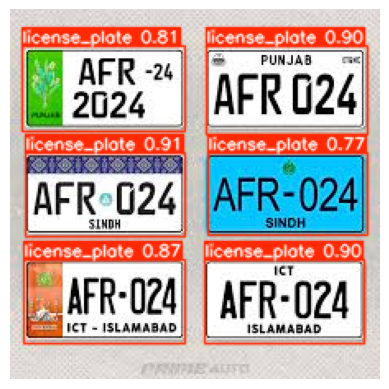

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
model = YOLO('weights/best.pt')

results = model('download.jpg')

annotated = results[0].plot(
    font_size=10,   # Smaller text
    line_width=1    # Thinner boxes
    )

plt.imshow(annotated)
plt.axis("off")
plt.show()


In [20]:
!pip install easyocr

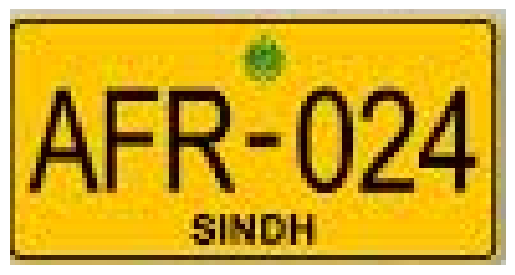

In [26]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


0: 640x640 6 license_plates, 13.8ms
Speed: 2.7ms preprocess, 13.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

Detected Plate:
Text: AFR024
Confidence: 1.0
Text: SJNDH
Confidence: 0.34


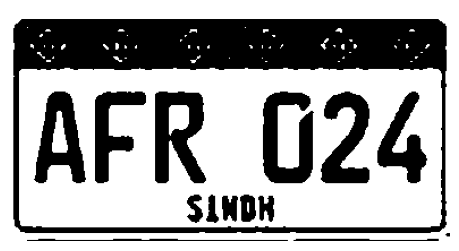


Detected Plate:
Text: PUNJAB
Confidence: 0.81
Text: 760
Confidence: 0.13
Text: AFR024
Confidence: 1.0


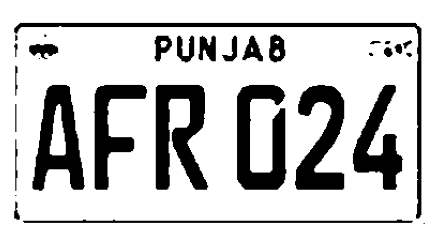


Detected Plate:
Text: AFR-024
Confidence: 0.84
Text: ISLAMABAD
Confidence: 0.91


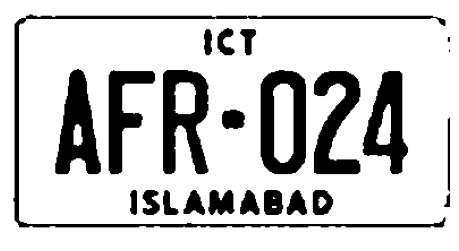


Detected Plate:
Text: AFR-0247
Confidence: 0.53
Text: ICT
Confidence: 0.99
Text: ISLAMABAD
Confidence: 0.89


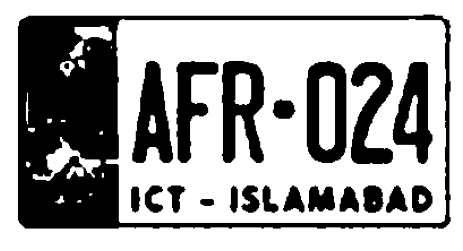


Detected Plate:
Text: AFR--4
Confidence: 0.95
Text: 2024
Confidence: 0.88


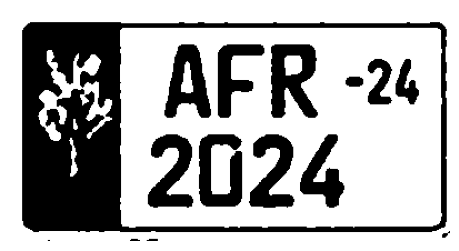


Detected Plate:
Text: AFR-024
Confidence: 0.97
Text: S1NDH
Confidence: 0.54


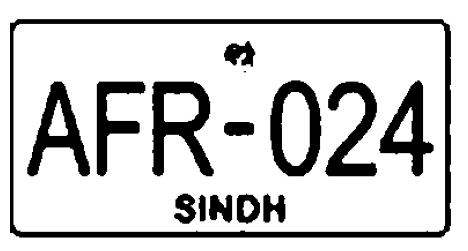

In [ ]:
from ultralytics import YOLO
import easyocr
import cv2
import matplotlib.pyplot as plt

# Load YOLO model
model = YOLO('weights/best.pt')

# Load EasyOCR
reader = easyocr.Reader(['en'])

# Read image
image = cv2.imread('download.jpg')

# Detect license plate
results = model(image)

# Process each detected plate
for box in results[0].boxes:

    # Bounding box coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Crop license plate
    plate = image[y1:y2, x1:x2]

    # Skip if crop is empty
    if plate.size == 0:
        continue

    # Enlarge image
    plate = cv2.resize(
        plate,
        None,
        fx=4,
        fy=4,
        interpolation=cv2.INTER_CUBIC
    )

    # Convert to grayscale
    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

    # Reduce noise
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    # Threshold
    thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    # OCR
    result = reader.readtext(
        thresh,
        allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-'
    )

    print("\nDetected Plate:")

    if result:
        for detection in result:
            print("Text:", detection[1])
            print("Confidence:", round(detection[2], 2))
    else:
        print("No text found.")

    # Show processed plate
    plt.figure(figsize=(8,3))
    plt.imshow(thresh, cmap='gray')
    plt.axis("off")
    plt.show()